In [1]:
import numpy as np
# numpy: numeric python, 행렬/벡터 등 수학 연산을 위한 라이브러리
import pandas as pd

In [2]:
from tensorflow.keras.models import Sequential
# Sequential: layer를 순차적으로 쌓아서 만드는 기본적인 ANN model 형태
from tensorflow.keras.layers import Input,Dense
# Input: input layer(ANN 모델의 입력이 어떠한 형태인지 알려줌)
# Dense: hidden layer와 output layer 등 layer 사이의 모든 node간에 가중치(연결강도)가 존재하는 layer
#        node의 수, activation function 등 정의할 수 있음

## 1. Data load

In [3]:
iris = pd.read_csv('Iris.csv')
# DataFrame.head(n): DataFrame의 상위 n개의 행만 반환
iris.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Setosa,Versicolor,Virginica
0,1,5.1,3.5,1.4,0.2,1,0,0
1,2,4.9,3.0,1.4,0.2,1,0,0
2,3,4.7,3.2,1.3,0.2,1,0,0
3,4,4.6,3.1,1.5,0.2,1,0,0
4,5,5.0,3.6,1.4,0.2,1,0,0


## 2. X와 y분리
- **Iris.csv**: 붓꽃의 종류를 분류하기 위한 데이터
- **Id**: 의미없는 행의 index
- **SepalLength, SepalWidth, PetalLength, PetalWidth**: 붓꽃의 species를 분류하기 위한 4개의 특징(꽃잎/꽃받침의 길이와 폭)
> - **X**: **SepalLength, SepalWidth, PetalLength, PetalWidth** 4개의 특징으로 구성
- **Setosa, Versicolor, Virginica**: 붓꽃의 species(class)
> - ex> **Versicolor**인 경우, `Versicolor`는 **1**, `Setosa`와 `Virginica`는 **0**의 값을 가짐
> - **y**: **Setosa, Versicolor, Virginica** 3개의 열, class로 구성
- `LinearRegression, LogisticRegression` 등을 포함한 **sklearn**의 경우, **X**를 **DataFrame**으로 사용해도 무방하나, **tensorflow**의 경우, **numpy**의 **ndarray**를 사용하는 것이 좋음
- **DataFrame.values**를 적용하면, `columns`, `index` 정보를 제외한 순수한 값(**value**)만 **ndarray** 타입으로 반환함

In [4]:
X = iris.drop(columns=['Id','Setosa','Versicolor','Virginica']).values
y = iris[['Setosa','Versicolor','Virginica']].values

- **ndarray.shape**은 **ndarray**의 행과 열의 수를 확인할 수 있음
> - **ndarray.shape = (a,b)**: `a`-> 행의 수, `b`-> 열의 수

In [5]:
print(X.shape, y.shape)

(150, 4) (150, 3)


- **X.shape** = **(데이터 샘플의 수, 특징의 수)**
> - **X.shape = (150,4)**: (**150송이의 붓꽃, SepalLength, SepalWidth, PetalLength, PetalWidth 4개의 특징**)
- **y.shape** = **(데이터의 샘플의 수, class의 수)**
> - **y.shape = (150,3)**: (**150송이의 붓꽃, Setosa/Versicolor/Virginica 3개 class**)

## 3. Training/Test data 분리

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(112, 4) (38, 4) (112, 3) (38, 3)


## 4. ANN 구조 정의
- **input layer node의 수**: **4**
- **hidden layer node의 수**: 개발자가 결정
- **output layer node의 수**: **3**
- **activation function**
> - hidden layer: **ReLu**
> - output layer: **softmax**
- **Sequential([layer1,layer2,layer3,...])**: input layer부터 output layer까지 순차적으로 **layer**를 쌓아서 **ANN model**을 구성함
- **Input(shape)**: input layer를 정의, shape은 **하나의 sample에 대한 shape**을 의미함, 즉 붓꽃 1개에 대한 shape을 의미함
- **Dense(units,activation)**
> - **units**: node의 수
> - **activation**: activation function(`relu`,`sigmoid`,`tanh`, `softmax` 등)


In [8]:
iris_model = Sequential([
    # input layer, 하나의 샘플에 대한 shape 지정(input layer의 node를 결정)
    # shape은 하나의 샘플을 의미하는 X_train[0]의 shape과 동일함
    # 하나의 입력 sample을 통해 input layer의 형태(node의 수)가 결정됨
    Input(shape=(4,)),
    # hidden layer, node의 수는 자유롭게 결정, activation function은 ReLu로 함
    Dense(units=16,activation='relu'),
    # output layer, node의 수는 class의 수와 동일, activation function은 softmax로 함
    # class의 수는 y_test 또는 y_train의 열의 수와 동일함 (y_train.shape[1])
    Dense(units=3,activation='softmax')
])

- `model.summary()`: 생성된 모델의 정보를 확인

In [9]:
iris_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. 학습 환경 설정

- **model.compile(optimizer,loss,metrics)**
> - `optimizer`: 최소값을 찾는 방법 (rmsprop, momentum, adam)
> - `loss`: cost/loss function
>> - y가 One-Hot Encoding된 형태(ex> [0,1,0],[0,0,1],[1,0,0],...)인 경우: `categorical_crossentropy`
>> - y가 0부터 시작하는 정수값을 갖는 1열의 값(ex> [0,1,2,1,1,2,0,0,...])인 경우: `sparse_categorical_crossentropy`
> - `metrics`: 학습과정에서 확인할 척도

In [10]:
iris_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['acc'])

## 6. 학습

- **model.fit(X,y,validation_split,validata_data,epochs,batch_size)**
> - `X,y`: 학습용 데이터
> - `validataion_split`: 학습 과정 중 성능 평가를 위한 데이터 비율 (optional)
> - `validataion_data`: 학습 과정 중 성능 평가를 위한 데이터 지정 (optional, validation_split과 validation_data 둘 중 하나만 사용)
> - `epochs`: 학습량 (모든 학습 데이터가 학습에 반영되는 횟수)
> - `batch_size`: 한번의 파라미터 업데이트에 활용되는 데이터 그룹이 포함한 데이터 수

In [11]:
result = iris_model.fit(X_train,y_train,
                        validation_split = 0.2, # 학습과정중 성능평가를 위해 사용되는 데이터 비율
                        epochs = 50,
                        batch_size = 8)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.4076 - loss: 2.0712 - val_acc: 0.3043 - val_loss: 2.1645
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.4154 - loss: 1.4464 - val_acc: 0.3043 - val_loss: 1.6604
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.4350 - loss: 1.1088 - val_acc: 0.3913 - val_loss: 1.2735
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.6931 - loss: 0.9874 - val_acc: 0.5217 - val_loss: 1.0386
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.6884 - loss: 0.9098 - val_acc: 0.5217 - val_loss: 0.8896
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.6850 - loss: 0.8173 - val_acc: 0.7391 - val_loss: 0.7832
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7778 - loss: 0.7491 - val_acc: 0.8696 - val_loss: 0.7323
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.6957 - loss: 0.7194 - val_acc: 0.7391 - val_loss: 0.7251
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7350 - loss

## 7. 결과 시각화

In [12]:
import matplotlib.pyplot as plt
# 데이터 시각화를 위한 라이브러리, 모듈

- **plt.plot(x)**: 가로축을 index를 세로축 값을 `x`로 하는 선차트를 그림
- `model.fit`의 결과를 **result**라고 할 때, **result.histroy['loss'], result.histroy['acc']** 를 통해 학습과정에서의 loss와 accuracy 등을 확인할 수 있음

Text(0, 0.5, 'loss')

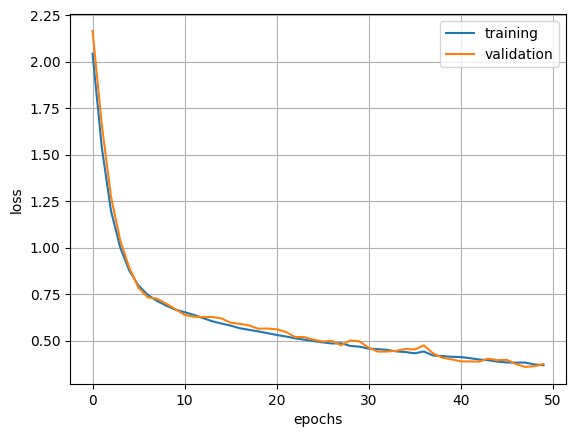

In [22]:
plt.plot(result.history['loss'],label='training')
plt.plot(result.history['val_loss'],label='validation')
# plt.plot을 연속으로 실행하면 두 차트가 중복되어 다른 색상으로 그려짐
# 만약 새로운 차트로 나타내고자 한다면, 두번째 plt.plot 전에
# plt.figure()를 실행함
plt.legend() # 각 차트의 label을 표시함
plt.grid() # 격자를 보여줌
plt.xlabel('epochs') # 가로축 이름 표시
plt.ylabel('loss') # 새로축 이름 표시